In [45]:
import os
import cv2
import numpy as np
import pandas as pd
import optuna
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import lightgbm as lgb

In [ ]:
DATASET_PATH = "train_cropped/"
SEASON_LABELS = {"autunno": 0, "estate": 1, "inverno": 2, "primavera": 3}

In [33]:
X = []
y = []

In [34]:
def get_average_color(image_path):

    if not os.path.exists(image_path):
        return np.array([0, 0, 0])

    image = cv2.imread(image_path)

    if image is None:
        return np.array([0, 0, 0])

    image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    avg_color = np.mean(image_hsv.reshape(-1, 3), axis=0)
    return avg_color  # [H, S, V]

In [35]:
file_names = []
for season in os.listdir(DATASET_PATH):
    season_path = os.path.join(DATASET_PATH, season)

    if not os.path.isdir(season_path) or season not in SEASON_LABELS:
        continue

    for subtype in os.listdir(season_path):
        subtype_path = os.path.join(season_path, subtype)

        if not os.path.isdir(subtype_path):
            continue

        hair_path = os.path.join(subtype_path, "hair")
        right_eye_path = os.path.join(subtype_path, "r_eye")
        left_eye_path = os.path.join(subtype_path, "l_eye")
        skin_path = os.path.join(subtype_path, "face")

        for file in os.listdir(skin_path):
            if file.endswith(".jpg") or file.endswith(".png"):
                file_name = file[:-15]
                print(file_name)

                skin_img = os.path.join(skin_path, f"{file_name}_face_color.png")
                hair_img = os.path.join(hair_path, f"{file_name}_hair_color.png")
                right_eye_img = os.path.join(right_eye_path, f"{file_name}_r_eye_color.png")
                left_eye_img = os.path.join(left_eye_path, f"{file_name}_l_eye_color.png")

                skin_color = get_average_color(skin_img)
                hair_color = get_average_color(hair_img)
                right_eye_color = get_average_color(right_eye_img)
                left_eye_color = get_average_color(left_eye_img)
                eyes_color = np.mean([left_eye_color, right_eye_color], axis = 0)

                X.append(np.concatenate([skin_color, hair_color, eyes_color]))
                y.append(SEASON_LABELS[season])
                file_names.append(file_name)



29719
images-15_2
images-101_1
images-97_1
4318
images-70_2
11658
12639
images-89_2
6547
images-51_2
images-142
images-157
6045
images-120_1
images-126
images-133
images-34_2
19289
Kate Winslet 3
28761
6771
4980
25749
Jennifer Aniston 3
images-45_2
1535
11730
images-129
23464
images-20_2
images-158
17946
Kate Moss 2
19912
images-150
images-145
images-115_1
20235
6154
images-6_2
Brad Pitt 1
10644
carmen-chaplin-SOFT SUMMER
images-64_2
images-134
images-82_2
6378
26334
17465
3297
images-2_2
images-111_1
images-144
images-151
12328
Lara Stone 1
2698
images-60_2
images-86_2
22110
images-135
24956
3260
simon baker-ESTATE SOFT
images-128
images-41_2
12924
Jennifer Aniston 2
26729
images-98_1
Michelle Hunziker SOFT SUMMER
Kate Moss 3
images-159
Rami Malek SOFT SUMMER
18971
images-24_2
Emilia Clarke SOFT SUMMER
images-156
images-143
images-55_2
Kate Winslet 2
images-30_2
10256
images-132
images-9_2
images-127
22199
874
19452
images-105_1
3904
images-11_2
17223
images-92_2
images-74_2
2536
7215

In [36]:
X = np.array(X)
y = np.array(y)

In [37]:
df = pd.DataFrame(X, columns=["skin_H", "skin_S", "skin_V", "hair_H", "hair_S", "hair_V", "eyes_H", "eyes_S", "eyes_V"])
df['file_name'] = file_names
df["season"] = y
df.to_csv("color_data.csv", index=False)

In [38]:
df = df.drop(columns=['file_name'])

In [39]:
df

,skin_H,skin_S,skin_V,hair_H,hair_S,hair_V,eyes_H,eyes_S,eyes_V,season
0,3.001152,31.012260,39.256420,4.166130,23.415546,31.617817,0.050259,0.346134,0.278866,1
1,2.270011,26.676423,48.585566,2.929939,22.092383,21.121201,0.252736,0.167161,0.255423,1
2,1.697624,10.441758,30.748483,7.329235,14.142442,55.691471,0.155321,0.105721,0.202293,1
3,1.748869,18.678089,42.956819,4.713803,33.713099,60.944306,0.050257,0.259759,0.368413,1
4,6.462616,22.881310,56.126400,15.128227,15.877605,3.981701,0.183426,0.172348,0.167862,1
...,...,...,...,...,...,...,...,...,...,...
4003,0.660105,9.517676,17.634997,3.368224,47.198383,42.312259,0.010759,0.130455,0.183415,0
4004,3.757874,17.689854,45.142239,15.745724,45.645977,44.393661,0.224144,0.156889,0.327745,0
4005,1.241457,10.440204,26.984475,4.380267,61.444245,39.691414,0.020294,0.168498,0.143322,0
4006,2.966328,56.542980,48.050011,1.737614,26.797642,22.589363,0.104469,0.462473,0.101229,0


In [ ]:
X = df.drop(columns=['season'])
y = df['season']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Then, split Temp into Validation (10%) and Test (10%) while preserving class distribution
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Verify class distribution
print("Class Distribution in Train Set:\n", y_train.value_counts(normalize=True))
print("\nClass Distribution in Validation Set:\n", y_valid.value_counts(normalize=True))
print("\nClass Distribution in Test Set:\n", y_test.value_counts(normalize=True))

Class Distribution in Train Set:
 0    0.261073
2    0.259825
3    0.243918
1    0.235184
Name: season, dtype: float64

Class Distribution in Validation Set:
 2    0.259352
0    0.259352
3    0.244389
1    0.236908
Name: season, dtype: float64

Class Distribution in Test Set:
 0    0.261845
2    0.259352
3    0.244389
1    0.234414
Name: season, dtype: float64


In [53]:
# Initialize and train the RandomForest model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Make predictions on the validation set
y_valid_pred = clf.predict(X_valid)

# Evaluate on validation set
valid_accuracy = accuracy_score(y_valid, y_valid_pred)
print(f"Validation Accuracy: {valid_accuracy:.4f}")

Validation Accuracy: 0.5012


In [54]:
y_test_pred = clf.predict(X_test)

# Evaluate on test set
test_accuracy = accuracy_score(y_test, y_test_pred)
report = classification_report(y_test, y_test_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print("Classification Report:\n", report)

Test Accuracy: 0.5137
Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.50      0.47       105
           1       0.57      0.56      0.57        94
           2       0.57      0.57      0.57       104
           3       0.49      0.42      0.45        98

    accuracy                           0.51       401
   macro avg       0.52      0.51      0.51       401
weighted avg       0.52      0.51      0.51       401



Text(0.5, 1.0, 'Confusion Matrix')

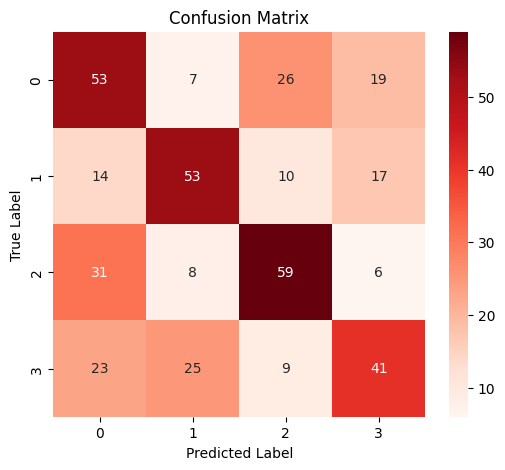

In [56]:
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Reds", xticklabels=set(y), yticklabels=set(y))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

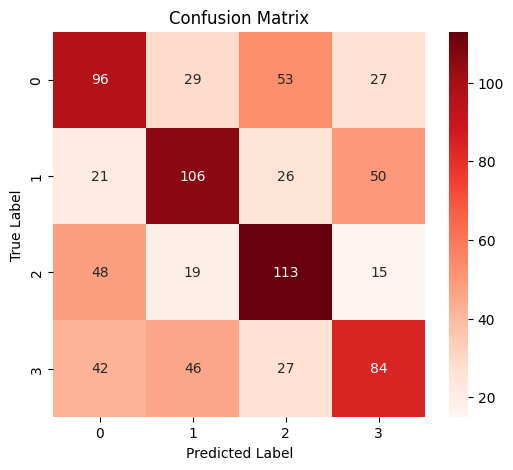

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Reds", xticklabels=set(y), yticklabels=set(y))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [44]:
clf = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000302 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 3206, number of used features: 9
[LightGBM] [Info] Start training from score -1.338188
[LightGBM] [Info] Start training from score -1.466129
[LightGBM] [Info] Start training from score -1.332260
[LightGBM] [Info] Start training from score -1.414768
Accuracy: 0.4788
Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.45      0.45       205
           1       0.53      0.48      0.50       203
           2       0.48      0.55      0.52       195
           3       0.46      0.43      0.45       199

    accuracy                           0.48       802
   macro avg       0.48      0.48      0.48       802
weighted avg       0.48      0.48      0.48       802



In [47]:
def objective(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_uniform("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_uniform("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_loguniform("reg_alpha", 1e-8, 10.0),
        "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-8, 10.0)
    }

    # Train LightGBM with trial parameters
    clf = lgb.LGBMClassifier(**params, random_state=42)
    clf.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy  # Optuna will maximize this value

# Run Optuna optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

# Get the best parameters
best_params = study.best_params
print("Best Parameters:", best_params)

# Train final model with optimized parameters
best_model = lgb.LGBMClassifier(**best_params, random_state=42)
best_model.fit(X_train, y_train)

# Make final predictions
y_pred = best_model.predict(X_test)

# Evaluate final model
final_accuracy = accuracy_score(y_test, y_pred)
print(f"Final Accuracy: {final_accuracy:.4f}")

[I 2025-03-13 22:13:25,485] A new study created in memory with name: no-name-0029f20e-3a41-482a-882e-587bf9c735f4
/var/folders/cl/wqxhc67j255bdr0rmv_bl3580000gn/T/ipykernel_94211/2583430703.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
/var/folders/cl/wqxhc67j255bdr0rmv_bl3580000gn/T/ipykernel_94211/2583430703.py:8: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  "subsample": trial.suggest_uniform("subsample", 0.5, 1.0),
/var/folders/cl/wqxhc67j255bdr0rmv_bl3580000gn/T/ipykernel_94211/2583430703.py:9: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000411 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 3206, number of used features: 9
[LightGBM] [Info] Start training from score -1.338188
[LightGBM] [Info] Start training from score -1.466129
[LightGBM] [Info] Start training from score -1.332260
[LightGBM] [Info] Start training from score -1.414768
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

[I 2025-03-13 22:13:26,303] Trial 0 finished with value: 0.49625935162094764 and parameters: {'num_leaves': 136, 'learning_rate': 0.09297902365486488, 'n_estimators': 252, 'max_depth': 3, 'min_child_samples': 14, 'subsample': 0.9815871890655179, 'colsample_bytree': 0.5814203827705717, 'reg_alpha': 2.1626166924285163e-06, 'reg_lambda': 5.6507494344525214e-05}. Best is trial 0 with value: 0.49625935162094764.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/var/folders/cl/wqxhc67j255bdr0rmv_bl3580000gn/T/ipykernel_94211/2583430703.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
/var/folders/cl/wqxhc67j255bdr0rmv_bl3580000gn/T/ipykernel_94211/2583430703.py:8: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  "subsample": trial.suggest_uniform("subsample", 0.5, 1.0),
/var/folders/cl/wqxhc67j255bdr0rmv_bl3580000gn/T/ipykernel_94211/2583430703.py:9: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  "colsample_bytree": trial.suggest_unifo

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/var/folders/cl/wqxhc67j255bdr0rmv_bl3580000gn/T/ipykernel_94211/2583430703.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
/var/folders/cl/wqxhc67j255bdr0rmv_bl3580000gn/T/ipykernel_94211/2583430703.py:8: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  "subsample": trial.suggest_uniform("subsample", 0.5, 1.0),
/var/folders/cl/wqxhc67j255bdr0rmv_bl3580000gn/T/ipykernel_94211/2583430703.py:9: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  "colsample_bytree": trial.suggest_unifo

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-03-13 22:15:44,214] Trial 49 finished with value: 0.5174563591022444 and parameters: {'num_leaves': 177, 'learning_rate': 0.020461490617308314, 'n_estimators': 271, 'max_depth': 4, 'min_child_samples': 20, 'subsample': 0.7028559132929566, 'colsample_bytree': 0.9954777800390338, 'reg_alpha': 0.15989474127795641, 'reg_lambda': 0.07258721676612041}. Best is trial 42 with value: 0.5261845386533666.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

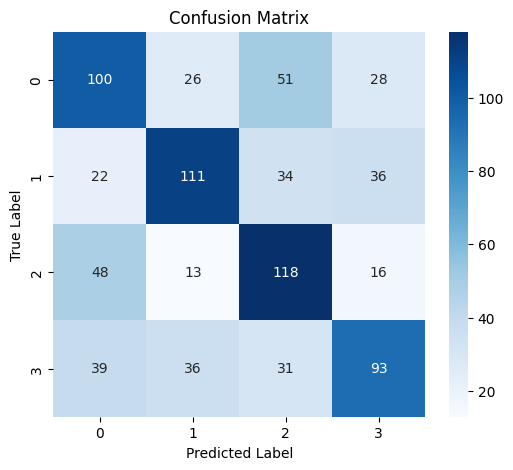

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=set(y), yticklabels=set(y))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
